# Notebook 02: Exploratory Spectral Analysis & Species Profiles

## Research Reference
**"An approach for accurate identification and monitoring of species in mangrove forests based on multi-source spectral data and deep learning"**  
*Monterrubio-Martínez et al., Ecological Informatics 85 (2025) 102961*

## Objective
Analyze the multispectral signatures and reflectance distributions of the three monospecific mangrove species (*Rhizophora mangle*, *Avicennia germinans*, and *Laguncularia racemosa*) across the 10 Sentinel-2 bands:
- RGB bands (Band 2, 3, 4)
- Vegetation Red Edge bands (Band 5, 6, 7, 8A)
- Near-Infrared band (Band 8)
- Short-Wave Infrared bands (Band 11, 12)

We compute spectral signatures, band correlation matrices, and reflectance distributions to understand the physical basis for species separability.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    SPECTRAL_BANDS,
    BAND_NAMES,
    BAND_WAVELENGTHS,
    SPECIES_NAMES,
    SPECIES_COLORS,
    RESULTS_FIGURES_DIR,
)
from src.data.loader import load_raw_data, sample_balanced_3species

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Load Balanced 3-Species Dataset (30,000 Pixels)

To ensure fair visual comparisons and avoid skew from the 89.8% dominance of *A. germinans*, we draw a balanced sample of 10,000 pixels per species (30,000 total pixels).

In [2]:
print("Loading dataset...")
df_raw = load_raw_data()
df_balanced = sample_balanced_3species(df_raw, samples_per_class=10000, random_seed=42)

print("Balanced dataset shape:", df_balanced.shape)
print(df_balanced["Spp"].value_counts())

Loading dataset...


Balanced dataset shape: (30000, 12)
Spp
Rhizophora_mangle        10000
Laguncularia_racemosa    10000
Avicennia_germinans      10000
Name: count, dtype: int64


## 2. Spectral Reflectance Statistics per Band & Species

Let us compute the mean and standard deviation for each spectral band across all three species.

In [3]:
summary_stats = df_balanced.groupby("Spp")[SPECTRAL_BANDS].agg(["mean", "std"]).T
display(summary_stats.round(4))

# Export summary table
RESULTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
summary_stats.to_csv(RESULTS_FIGURES_DIR.parent / "tables" / "spectral_summary_stats.csv")
print("Saved spectral statistics table.")

Spp           Avicennia_germinans  Laguncularia_racemosa  Rhizophora_mangle
Band_2  mean               0.0889                 0.0902             0.0897
        std                0.0015                 0.0020             0.0054
Band_3  mean               0.0809                 0.0847             0.0837
        std                0.0026                 0.0028             0.0073
Band_4  mean               0.0494                 0.0513             0.0509
        std                0.0024                 0.0030             0.0076
Band_5  mean               0.0856                 0.0905             0.0845
        std                0.0260                 0.0316             0.0297
Band_6  mean               0.1866                 0.2021             0.1768
        std                0.0247                 0.0318             0.0389
Band_7  mean               0.2353                 0.2518             0.2197
        std                0.0293                 0.0363             0.0472
Band_8  mean               0.2264                 0.2519             0.2489
        std                0.0205                 0.0210             0.0501
Band_8A mean               0.2593                 0.2803             0.2401
        std                0.0346                 0.0419             0.0549
Band_11 mean               0.0968                 0.0963             0.0782
        std                0.0313                 0.0329             0.0324
Band_12 mean               0.0421                 0.0402             0.0333
        std                0.0258                 0.0279             0.0253

Saved spectral statistics table.


## 3. Mean Spectral Signatures across Wavelengths

We plot the spectral reflectance curves across electromagnetic wavelengths (490 nm to 2190 nm) to visualize the distinct vegetation profiles.

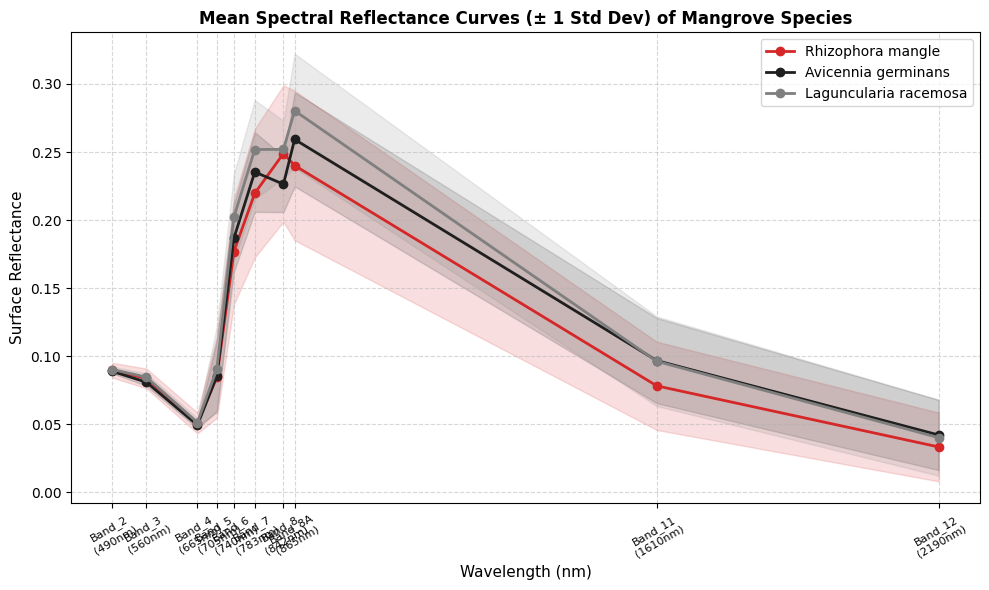

In [4]:
wavelengths = [BAND_WAVELENGTHS[b] for b in SPECTRAL_BANDS]

plt.figure(figsize=(10, 6))
for spp in ["Rhizophora_mangle", "Avicennia_germinans", "Laguncularia_racemosa"]:
    means = [df_balanced[df_balanced["Spp"] == spp][b].mean() for b in SPECTRAL_BANDS]
    stds = [df_balanced[df_balanced["Spp"] == spp][b].std() for b in SPECTRAL_BANDS]
    color = SPECIES_COLORS[spp]
    label = spp.replace("_", " ")
    
    plt.plot(wavelengths, means, "-o", label=label, color=color, linewidth=2, markersize=6)
    plt.fill_between(
        wavelengths,
        np.array(means) - np.array(stds),
        np.array(means) + np.array(stds),
        color=color,
        alpha=0.15
    )

plt.title("Mean Spectral Reflectance Curves (± 1 Std Dev) of Mangrove Species", fontsize=12, fontweight="bold")
plt.xlabel("Wavelength (nm)", fontsize=11)
plt.ylabel("Surface Reflectance", fontsize=11)
plt.xticks(wavelengths, [f"{b}\n({BAND_WAVELENGTHS[b]}nm)" for b in SPECTRAL_BANDS], rotation=30, fontsize=8)
plt.legend(frameon=True, fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()

plt.savefig(RESULTS_FIGURES_DIR / "spectral_signatures.png", dpi=300)
plt.show()

## 4. Spectral Band Correlation Matrix

We analyze collinearity across the 10 bands. Multispectral remote sensing bands exhibit significant inter-band correlation, particularly across adjacent red-edge and near-infrared bands.

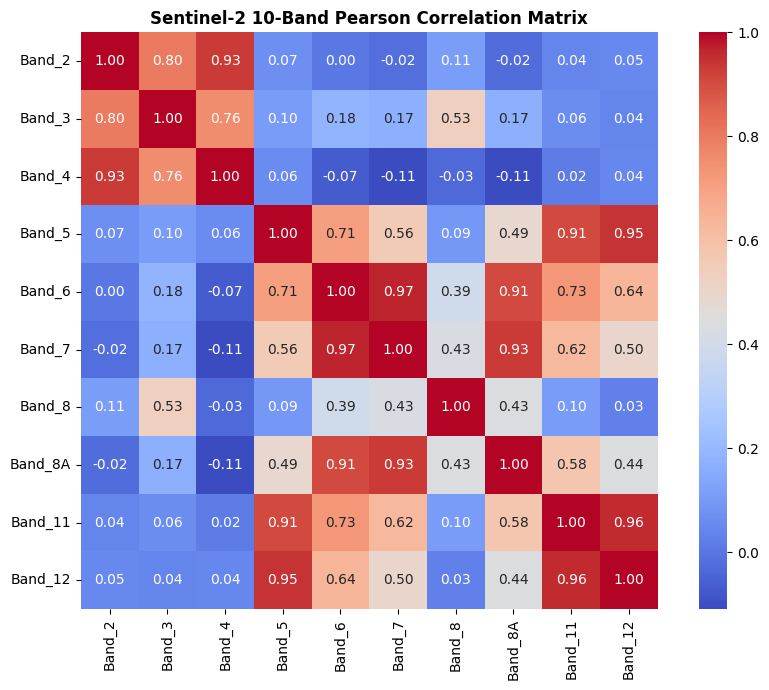

In [5]:
corr_matrix = df_balanced[SPECTRAL_BANDS].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Sentinel-2 10-Band Pearson Correlation Matrix", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES_DIR / "band_correlation_matrix.png", dpi=300)
plt.show()

## 5. Key Band Distributions (Red, NIR, SWIR)

Let us inspect the distribution shapes for key diagnostic spectral regions:
- **Band 4 (Red)**: Strong chlorophyll absorption region.
- **Band 8 (NIR)**: High cellular structure scattering plateau.
- **Band 11 (SWIR 1)**: Canopy water/moisture absorption region.

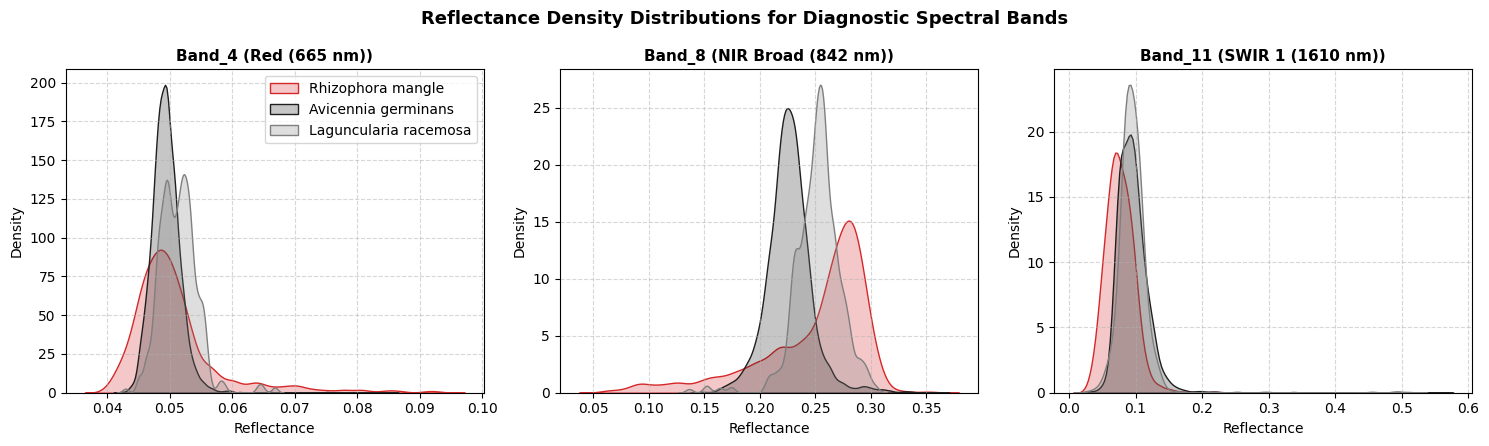

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sample_bands = ["Band_4", "Band_8", "Band_11"]

for idx, b in enumerate(sample_bands):
    ax = axes[idx]
    for spp in ["Rhizophora_mangle", "Avicennia_germinans", "Laguncularia_racemosa"]:
        sns.kdeplot(
            data=df_balanced[df_balanced["Spp"] == spp][b],
            label=spp.replace("_", " "),
            color=SPECIES_COLORS[spp],
            fill=True,
            alpha=0.25,
            ax=ax
        )
    ax.set_title(f"{b} ({BAND_NAMES[b]})", fontsize=11, fontweight="bold")
    ax.set_xlabel("Reflectance")
    ax.grid(True, linestyle="--", alpha=0.5)
    if idx == 0:
        ax.legend()

plt.suptitle("Reflectance Density Distributions for Diagnostic Spectral Bands", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_FIGURES_DIR / "diagnostic_band_distributions.png", dpi=300)
plt.show()